# Hybrid Monthly Sales Forecasting Notebook

This notebook demonstrates a hybrid time series forecasting workflow for **monthly sales** using:

- **Multivariate regression** to model the impact of external drivers
- **ARIMA** on regression residuals to capture autocorrelation and temporal structure
- **MAE / RMSE** for holdout evaluation
- **95% forecast confidence intervals**
- An **explainability layer** with:
  - regression coefficients
  - permutation importance
  - driver contribution decomposition
  - visual diagnostics

The notebook uses the synthetic dataset in `synthetic_monthly_sales.csv`.


In [9]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

#BASE_DIR = Path('/mnt/data') if Path('/mnt/data').exists() else Path(os.getcwd())
DATA_PATH =  "synthetic_monthly_sales.csv"
TRAIN_RATIO = 0.80
ARIMA_ORDER = (1, 0, 1)
FORECAST_HORIZON = 6

plt.rcParams["figure.figsize"] = (11, 5)

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out = out.sort_values("date").reset_index(drop=True)
    out["t"] = np.arange(len(out))
    out["month_num"] = out["date"].dt.month
    out["month_sin"] = np.sin(2 * np.pi * out["month_num"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["month_num"] / 12.0)
    return out

def build_feature_matrix(df: pd.DataFrame) -> list[str]:
    return [
        "marketing_spend",
        "avg_price",
        "economic_index",
        "holiday_flag",
        "competitor_promo_index",
        "t",
        "month_sin",
        "month_cos",
    ]

def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def fit_regression(train: pd.DataFrame, feature_cols: list[str]):
    X = sm.add_constant(train[feature_cols], has_constant="add")
    y = train["sales"]
    return sm.OLS(y, X).fit()

def fit_arima_on_residuals(train_residuals: pd.Series):
    return ARIMA(train_residuals, order=ARIMA_ORDER).fit()

def evaluate_forecast(actual: pd.Series, predicted: pd.Series) -> dict:
    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": rmse(actual, predicted),
    }

def explain_regression_effects(ols_model, feature_cols: list[str]) -> pd.DataFrame:
    coefs = pd.Series(ols_model.params, index=ols_model.params.index)
    return (
        pd.DataFrame({
            "feature": coefs.index,
            "coefficient": coefs.values,
            "abs_coefficient": coefs.abs().values,
        })
        .query("feature != 'const'")
        .sort_values("abs_coefficient", ascending=False)
        .drop(columns=["abs_coefficient"])
        .reset_index(drop=True)
    )

def standardized_feature_importance(train: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = train[feature_cols]
    y = train["sales"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ])
    model.fit(X, y)
    result = permutation_importance(
        model,
        X,
        y,
        n_repeats=20,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )
    return pd.DataFrame({
        "feature": feature_cols,
        "permutation_importance_mean": result.importances_mean,
        "permutation_importance_std": result.importances_std,
    }).sort_values("permutation_importance_mean", ascending=False)

def driver_contributions(ols_model, df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = sm.add_constant(df[feature_cols], has_constant="add")
    contrib = pd.DataFrame(index=df.index)
    for col in X.columns:
        contrib[f"contrib_{col}"] = X[col] * ols_model.params[col]
    contrib["regression_prediction"] = contrib.sum(axis=1)
    return contrib


Matplotlib created a temporary cache directory at /tmp/matplotlib-vbalb11b because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1) Load and inspect the synthetic monthly sales data

In [13]:
df = pd.read_csv(DATA_PATH)
df = add_time_features(df)
feature_cols = build_feature_matrix(df)

df.head()

,date,sales,marketing_spend,avg_price,economic_index,holiday_flag,competitor_promo_index,t,month_num,month_sin,month_cos
0,2019-01-01,25681.74,51241.79,21.33,100.76,0,24.37,0,1,0.500000,8.660254e-01
1,2019-02-01,26857.66,53404.34,21.13,100.90,0,14.17,1,2,0.866025,5.000000e-01
2,2019-03-01,28368.24,58181.40,21.24,101.24,0,6.51,2,3,1.000000,6.123234e-17
3,2019-04-01,28888.19,61557.57,20.69,101.63,0,16.55,3,4,0.866025,-5.000000e-01
4,2019-05-01,27757.81,56476.79,20.18,102.42,0,28.73,4,5,0.500000,-8.660254e-01


In [15]:
df.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
date,84,2022-06-16 14:17:08.571428608,2019-01-01 00:00:00,2020-09-23 12:00:00,2022-06-16 00:00:00,2024-03-08 18:00:00,2025-12-01 00:00:00,NaN
sales,84.0,30241.26619,25279.4,27877.885,30247.265,32737.62,36004.1,2759.527086
marketing_spend,84.0,60112.792976,44764.14,54255.8375,60024.04,66138.1175,77804.76,7748.219253
avg_price,84.0,22.254405,20.18,21.48,22.24,22.9325,24.94,1.035944
economic_index,84.0,105.20369,99.12,102.7825,105.195,107.335,112.05,3.272327
holiday_flag,84.0,0.166667,0.0,0.0,0.0,0.0,1.0,0.374916
competitor_promo_index,84.0,18.251548,6.51,13.4825,18.045,24.07,31.21,6.475577
t,84.0,41.5,0.0,20.75,41.5,62.25,83.0,24.392622
month_num,84.0,6.5,1.0,3.75,6.5,9.25,12.0,3.472786
month_sin,84.0,-0.0,-1.0,-0.591506,-0.0,0.591506,1.0,0.711354


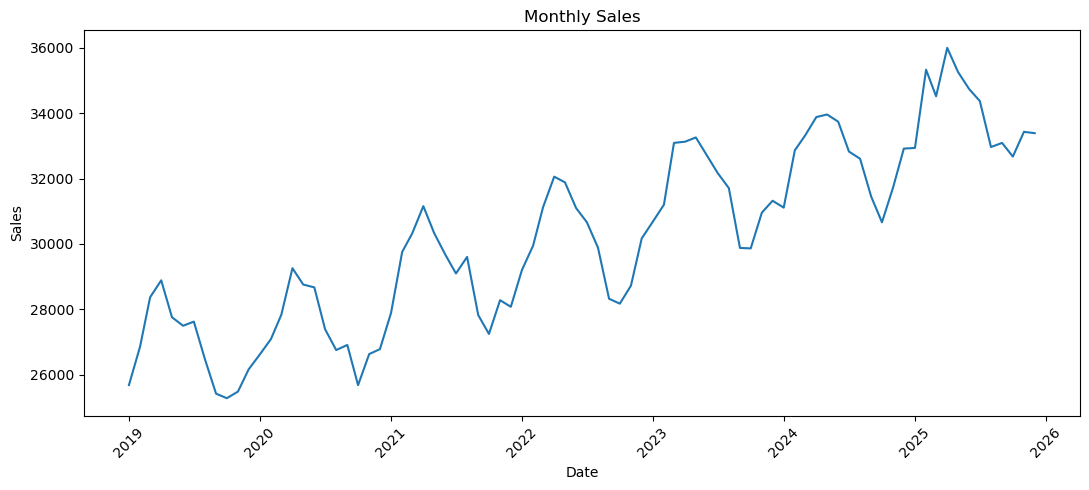

In [17]:
plt.figure()
plt.plot(df["date"], df["sales"])
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2) Train / test split

In [19]:
split_idx = int(len(df) * TRAIN_RATIO)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Training rows: {len(train)}")
print(f"Test rows: {len(test)}")
print(f"Training period: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test period: {test['date'].min().date()} to {test['date'].max().date()}")

Training rows: 67
Test rows: 17
Training period: 2019-01-01 to 2024-07-01
Test period: 2024-08-01 to 2025-12-01


## 3) Regression on external drivers

In [21]:
ols_model = fit_regression(train, feature_cols)

train_X = sm.add_constant(train[feature_cols], has_constant="add")
test_X = sm.add_constant(test[feature_cols], has_constant="add")

train["regression_pred"] = ols_model.predict(train_X)
test["regression_pred"] = ols_model.predict(test_X)

train["residual"] = train["sales"] - train["regression_pred"]

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     3084.
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           2.68e-73
Time:                        08:36:44   Log-Likelihood:                -413.42
No. Observations:                  67   AIC:                             844.8
Df Residuals:                      58   BIC:                             864.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1.19

In [25]:
coef_summary = explain_regression_effects(ols_model, feature_cols)
coef_summary

,feature,coefficient
0,holiday_flag,690.916064
1,month_cos,-555.730749
2,month_sin,548.715791
3,avg_price,-224.059140
4,economic_index,110.469370
5,t,56.690400
6,competitor_promo_index,-39.954128
7,marketing_spend,0.165078


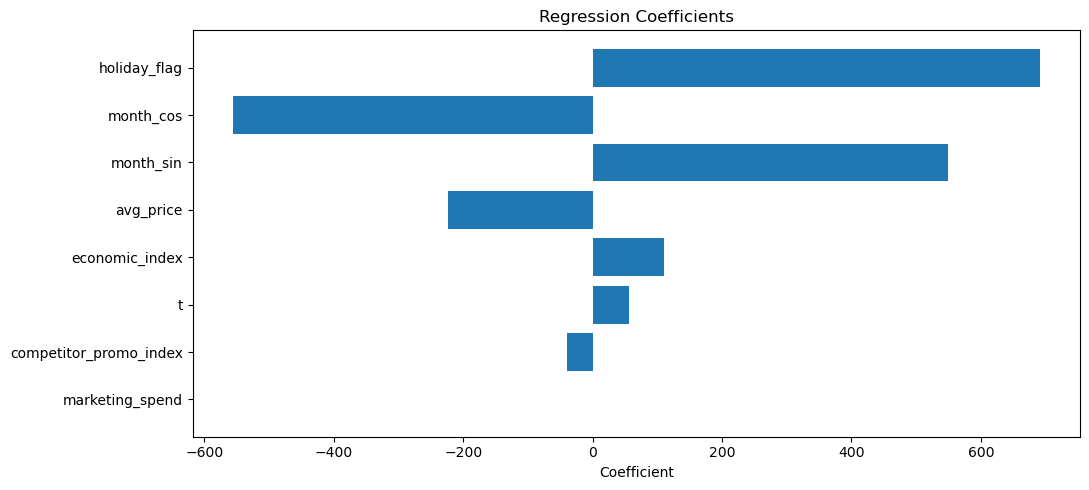

In [27]:
plt.figure()
plt.barh(coef_summary["feature"][::-1], coef_summary["coefficient"][::-1])
plt.title("Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## 4) ARIMA on regression residuals

In [29]:
arima_model = fit_arima_on_residuals(train["residual"])
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:               residual   No. Observations:                   67
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -402.534
Date:                Sat, 07 Mar 2026   AIC                            813.069
Time:                        08:37:28   BIC                            821.887
Sample:                             0   HQIC                           816.558
                                 - 67                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0480     24.852     -0.002      0.998     -48.756      48.660
ar.L1          0.4757      0.201      2.362      0.018       0.081       0.870
ma.L1          0.0752      0.199      0.377      0.7

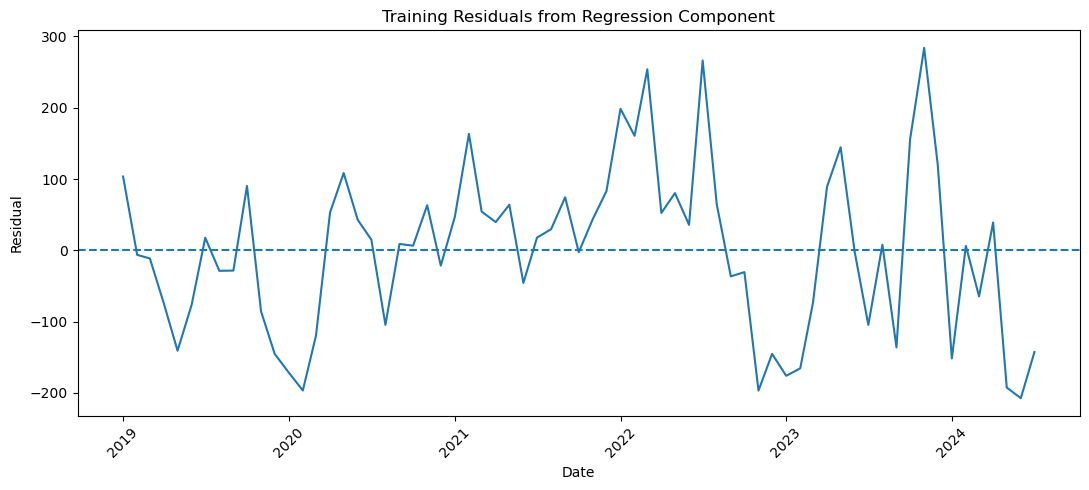

In [31]:
plt.figure()
plt.plot(train["date"], train["residual"])
plt.axhline(0, linestyle="--")
plt.title("Training Residuals from Regression Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5) Holdout forecast, confidence intervals, and performance

In [33]:
arima_forecast = arima_model.get_forecast(steps=len(test))
test["residual_forecast"] = arima_forecast.predicted_mean.values

ci = arima_forecast.conf_int(alpha=0.05)
lower_col = ci.columns[0]
upper_col = ci.columns[1]

test["hybrid_forecast"] = test["regression_pred"] + test["residual_forecast"]
test["forecast_lower_95"] = test["regression_pred"] + ci[lower_col].values
test["forecast_upper_95"] = test["regression_pred"] + ci[upper_col].values

metrics = evaluate_forecast(test["sales"], test["hybrid_forecast"])
print(json.dumps(metrics, indent=2))

test[["date", "sales", "hybrid_forecast", "forecast_lower_95", "forecast_upper_95"]].head(12)

{
  "MAE": 90.24064536756465,
  "RMSE": 120.03233248776334
}


,date,sales,hybrid_forecast,forecast_lower_95,forecast_upper_95
67,2024-08-01,32609.87,32616.492389,32424.114634,32808.870144
68,2024-09-01,31449.31,31490.348665,31270.708243,31709.989086
69,2024-10-01,30664.08,30592.690970,30367.339021,30818.042919
70,2024-11-01,31728.64,31782.226405,31555.602098,32008.850712
71,2024-12-01,32920.43,32910.527017,32683.615808,33137.438226
72,2025-01-01,32940.50,32998.501241,32771.525166,33225.477316
73,2025-02-01,35334.16,35338.965255,35111.974506,35565.956005
74,2025-03-01,34522.50,34521.525483,34294.531414,34748.519553
75,2025-04-01,36004.10,36167.940309,35940.945487,36394.935130
76,2025-05-01,35268.27,35565.921122,35338.926131,35792.916113


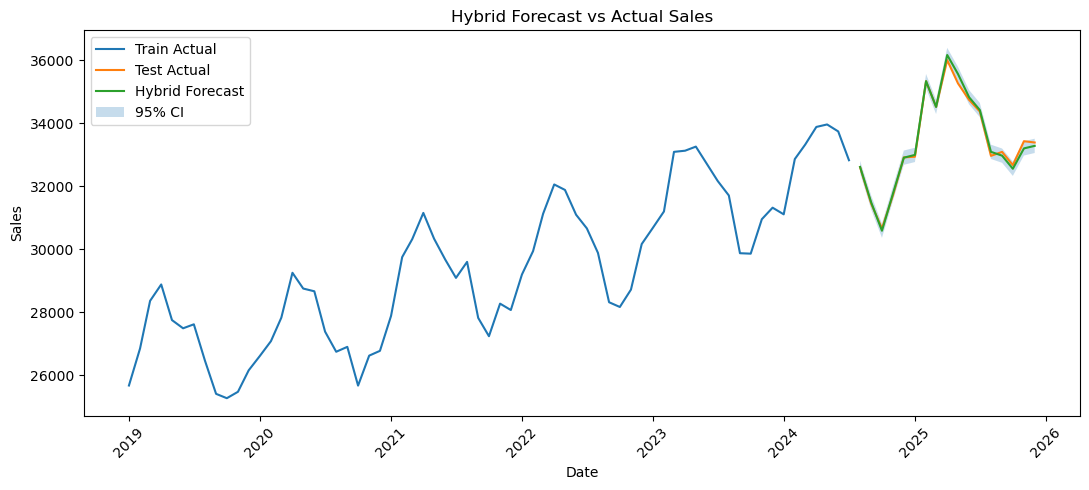

In [35]:
plt.figure()
plt.plot(train["date"], train["sales"], label="Train Actual")
plt.plot(test["date"], test["sales"], label="Test Actual")
plt.plot(test["date"], test["hybrid_forecast"], label="Hybrid Forecast")
plt.fill_between(
    test["date"],
    test["forecast_lower_95"],
    test["forecast_upper_95"],
    alpha=0.25,
    label="95% CI"
)
plt.title("Hybrid Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

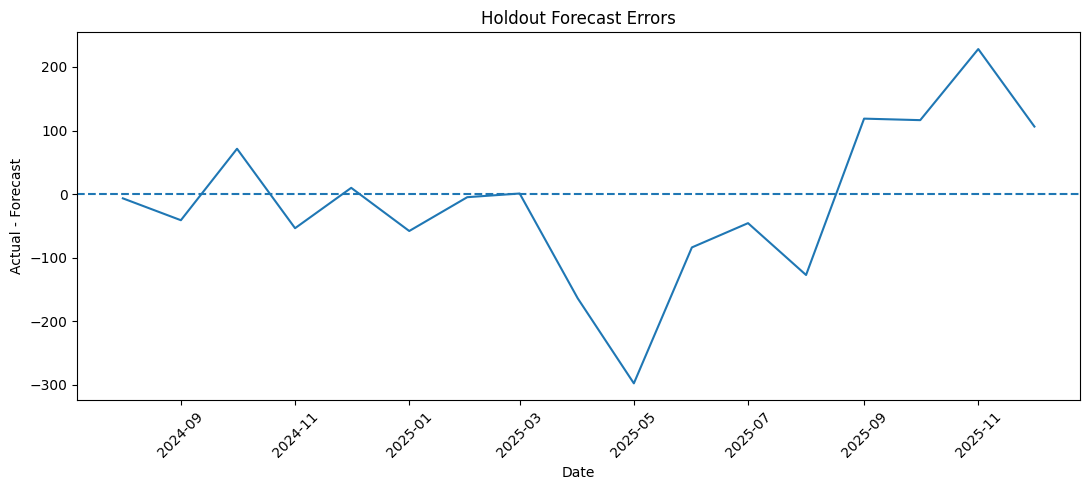

In [13]:
plt.figure()
errors = test["sales"] - test["hybrid_forecast"]
plt.plot(test["date"], errors)
plt.axhline(0, linestyle="--")
plt.title("Holdout Forecast Errors")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6) Explainability layer

In [37]:
perm_importance = standardized_feature_importance(train, feature_cols)
perm_importance

,feature,permutation_importance_mean,permutation_importance_std
0,marketing_spend,1270.553988,113.907534
5,t,1185.954303,136.584747
7,month_cos,385.780230,44.220840
6,month_sin,368.300186,37.282912
2,economic_index,234.231335,28.597727
4,competitor_promo_index,214.341356,17.167428
1,avg_price,144.350585,15.170494
3,holiday_flag,140.605418,20.087353


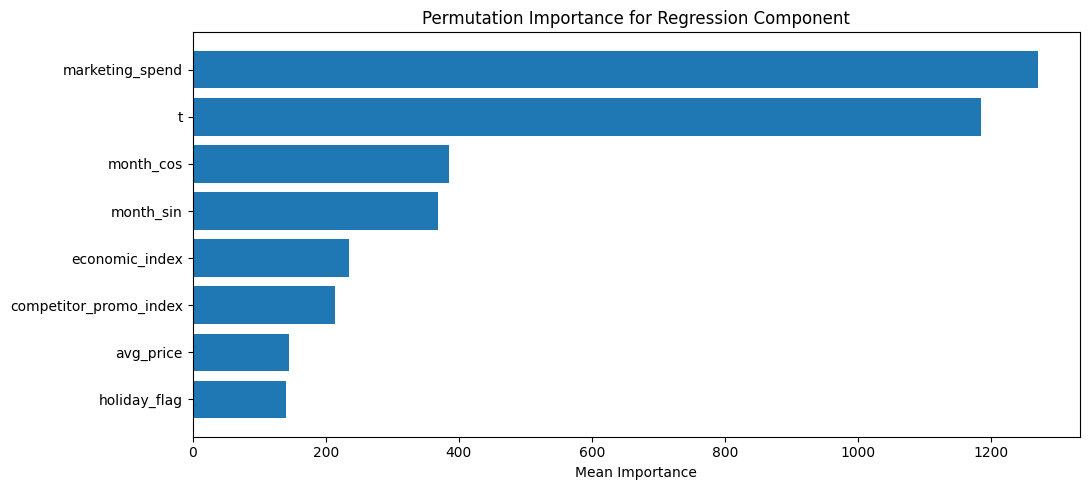

In [15]:
plt.figure()
ordered = perm_importance.sort_values("permutation_importance_mean")
plt.barh(ordered["feature"], ordered["permutation_importance_mean"])
plt.title("Permutation Importance for Regression Component")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [39]:
test_contrib = driver_contributions(ols_model, test, feature_cols)
explainable_forecast = pd.concat(
    [
        test[[
            "date", "sales", "regression_pred", "residual_forecast",
            "hybrid_forecast", "forecast_lower_95", "forecast_upper_95"
        ]].reset_index(drop=True),
        test_contrib.reset_index(drop=True),
    ],
    axis=1,
)

contribution_cols = [c for c in explainable_forecast.columns if c.startswith("contrib_")]
explainable_forecast.head()

,date,sales,regression_pred,residual_forecast,hybrid_forecast,forecast_lower_95,forecast_upper_95,contrib_const,contrib_marketing_spend,contrib_avg_price,contrib_economic_index,contrib_holiday_flag,contrib_competitor_promo_index,contrib_t,contrib_month_sin,contrib_month_cos,regression_prediction
0,2024-08-01,32609.87,32687.078907,-70.586518,32616.492389,32424.114634,32808.870144,11948.287691,10855.303349,-5121.991945,11831.269540,0.000000,-426.710089,3798.2568,-4.752018e+02,2.778654e+02,32687.078907
1,2024-09-01,31449.31,31523.950059,-33.601394,31490.348665,31270.708243,31709.989086,11948.287691,10208.707982,-5139.916676,11654.518548,0.000000,-453.878896,3854.9472,-5.487158e+02,1.020861e-13,31523.950059
2,2024-10-01,30664.08,30608.699475,-16.008505,30592.690970,30367.339021,30818.042919,11948.287691,9679.682463,-5303.479848,11916.330955,0.000000,-790.692197,3911.6376,-4.752018e+02,-2.778654e+02,30608.699475
3,2024-11-01,31728.64,31789.866418,-7.640013,31782.226405,31555.602098,32008.850712,11948.287691,10291.147687,-5366.216408,11910.807486,690.916064,-897.769260,3968.3280,-2.743579e+02,-4.812769e+02,31789.866418
4,2024-12-01,32920.43,32914.186350,-3.659333,32910.527017,32683.615808,33137.438226,11948.287691,11240.967312,-5303.479848,12115.175821,690.916064,-1246.968341,4025.0184,-1.343966e-13,-5.557307e+02,32914.186350


In [41]:
latest = explainable_forecast.tail(1).copy()
latest[["date", "hybrid_forecast"] + contribution_cols]

,date,hybrid_forecast,contrib_const,contrib_marketing_spend,contrib_avg_price,contrib_economic_index,contrib_holiday_flag,contrib_competitor_promo_index,contrib_t,contrib_month_sin,contrib_month_cos
16,2025-12-01,33285.724481,11948.287691,10887.57435,-5588.034956,12175.933975,690.916064,-978.476599,4705.3032,-1.343966e-13,-555.730749


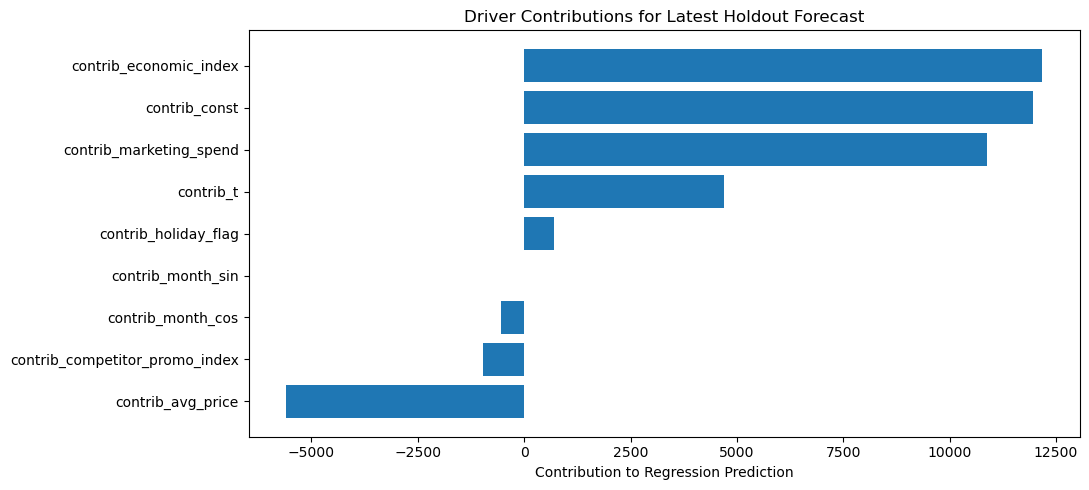

In [43]:
latest_row = explainable_forecast.iloc[-1]
latest_contrib = pd.DataFrame({
    "component": contribution_cols,
    "value": [latest_row[c] for c in contribution_cols]
}).sort_values("value")

plt.figure()
plt.barh(latest_contrib["component"], latest_contrib["value"])
plt.title("Driver Contributions for Latest Holdout Forecast")
plt.xlabel("Contribution to Regression Prediction")
plt.tight_layout()
plt.show()

## 7) Future forecast scenario

In [45]:
future = df.tail(FORECAST_HORIZON).copy()
future["date"] = pd.date_range(df["date"].max() + pd.offsets.MonthBegin(1), periods=FORECAST_HORIZON, freq="MS")
future["t"] = np.arange(len(df), len(df) + FORECAST_HORIZON)
future["month_num"] = future["date"].dt.month
future["month_sin"] = np.sin(2 * np.pi * future["month_num"] / 12.0)
future["month_cos"] = np.cos(2 * np.pi * future["month_num"] / 12.0)

future_X = sm.add_constant(future[feature_cols], has_constant="add")
future["regression_pred"] = ols_model.predict(future_X)

future_arima_fc = arima_model.get_forecast(steps=FORECAST_HORIZON)
future_ci = future_arima_fc.conf_int(alpha=0.05)
f_lower_col = future_ci.columns[0]
f_upper_col = future_ci.columns[1]

future["residual_forecast"] = future_arima_fc.predicted_mean.values
future["hybrid_forecast"] = future["regression_pred"] + future["residual_forecast"]
future["forecast_lower_95"] = future["regression_pred"] + future_ci[f_lower_col].values
future["forecast_upper_95"] = future["regression_pred"] + future_ci[f_upper_col].values

future_contrib = driver_contributions(ols_model, future, feature_cols)
future_explainable = pd.concat(
    [
        future[["date", "hybrid_forecast", "forecast_lower_95", "forecast_upper_95"]].reset_index(drop=True),
        future_contrib.reset_index(drop=True),
    ],
    axis=1,
)

future[["date", "hybrid_forecast", "forecast_lower_95", "forecast_upper_95"]]

,date,hybrid_forecast,forecast_lower_95,forecast_upper_95
78,2026-01-01,34276.844838,34084.467083,34469.222592
79,2026-02-01,33797.048183,33577.407762,34016.688605
80,2026-03-01,34396.486688,34171.134739,34621.838637
81,2026-04-01,34397.674434,34171.050127,34624.298741
82,2026-05-01,35052.820844,34825.909635,35279.732053
83,2026-06-01,34735.611049,34508.634973,34962.587124


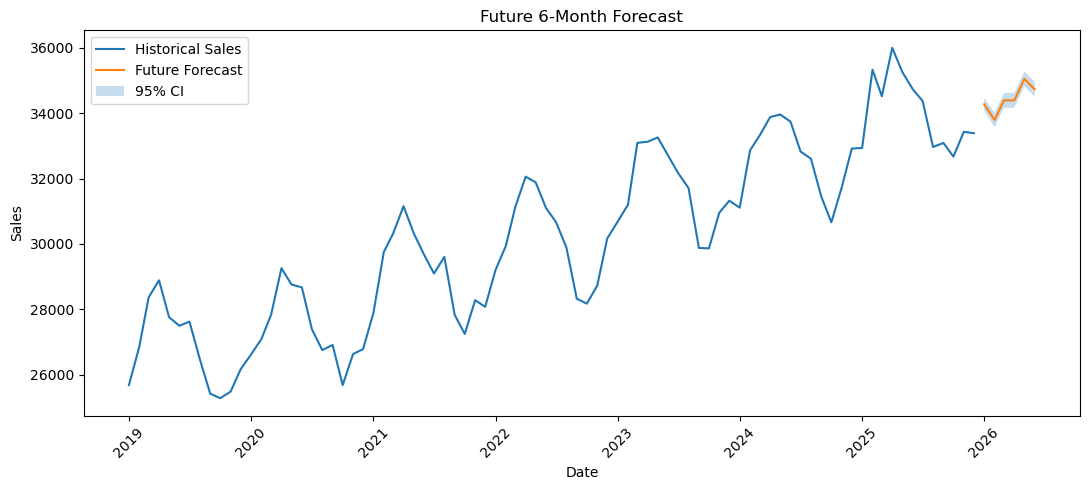

In [47]:
plt.figure()
plt.plot(df["date"], df["sales"], label="Historical Sales")
plt.plot(future["date"], future["hybrid_forecast"], label="Future Forecast")
plt.fill_between(
    future["date"],
    future["forecast_lower_95"],
    future["forecast_upper_95"],
    alpha=0.25,
    label="95% CI"
)
plt.title("Future 6-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8) Save outputs

In [21]:
forecast_output = test[
    [
        "date",
        "sales",
        "regression_pred",
        "residual_forecast",
        "hybrid_forecast",
        "forecast_lower_95",
        "forecast_upper_95",
    ]
].copy()

forecast_output.to_csv("hybrid_forecast_output.csv", index=False)
coef_summary.to_csv("regression_coefficients_explainability.csv", index=False)
perm_importance.to_csv("permutation_importance_explainability.csv", index=False)
explainable_forecast.to_csv("forecast_with_driver_contributions.csv", index=False)
future_explainable.to_csv("future_forecast_with_explainability.csv", index=False)

print("Saved:")
print("- hybrid_forecast_output.csv")
print("- regression_coefficients_explainability.csv")
print("- permutation_importance_explainability.csv")
print("- forecast_with_driver_contributions.csv")
print("- future_forecast_with_explainability.csv")

Saved:
- hybrid_forecast_output.csv
- regression_coefficients_explainability.csv
- permutation_importance_explainability.csv
- forecast_with_driver_contributions.csv
- future_forecast_with_explainability.csv
